# TS-SatFire -- Active Fire Detection -- Hybrid CNN-Transformer v1

## Architecture

A clean two-stage hybrid model:

1. **Shared CNN encoder** processes each of the T=6 timesteps independently with tied weights,
   producing a spatial feature map per timestep.
2. **Bottleneck Temporal Transformer** applies multi-head self-attention *only across the
   time axis* at the deepest (lowest resolution) feature level. This is cheap because
   spatial resolution is 8x downsampled at the bottleneck.
3. **CNN decoder** with skip connections from the encoder reconstructs the full-resolution
   prediction map.

The separation of concerns is explicit: CNN handles spatial texture, Transformer handles
temporal reasoning. This directly addresses the AF detection challenge identified in the
paper: fire pixels are spectrally subtle and only distinguishable from false positives
(hot rooftops, desert surfaces) through temporal context.

## Key differences from BA notebook (UNet3D v4)

| | BA UNet3D v4 | AF Hybrid v1 |
|---|---|---|
| Task | Burned area segmentation | Active fire detection |
| Architecture | 3D convolutions throughout | Shared 2D CNN + temporal attention |
| Time steps | T=2 | T=6 |
| Label source | FirePred channel 3 | VNP14IMG AF product |
| Label channel | ch3 of FirePred.tif | ch1 of VIIRS_Day.tif band I4 threshold |
| Output timestep | Last timestep | Current (last) timestep |
| Augmentation | None | H-flip + V-flip (always on for AF) |
| Base channels | 32 | 48 |
| Transformer depth | None | 4 layers at bottleneck only |

## Label strategy for AF

The AF labels in TS-SatFire are sourced from the NASA VNP14IMG product stored in
VIIRS_Day GeoTIFFs. Band 7 (index 6, zero-based) of the day image is the VNP14IMG
fire mask. Values > 7 indicate nominal fire detection confidence.
For the test set the labels are manually annotated -- those are separate files.

The paper notes the AF test set has 17 fires across multiple continents (2018-2022),
separate from the BA test set which uses 2021 US fires only.

## Pipeline diagnostic plots

This notebook produces extensive diagnostic plots at every stage to help diagnose
issues in future versions:
- Dataset statistics and label distribution
- Channel-wise normalisation statistics with outlier detection
- Label quality sanity checks per fire
- Architecture diagram (text-based) with parameter counts per block
- Gradient flow plot after first batch
- Class balance across training batches
- Per-epoch training curves with confidence bands
- Attention weight visualisation at bottleneck
- Prediction sample grid every 5 epochs

In [1]:
import os
import sys
import glob
import json
import math
import random
import warnings
import time
import zipfile
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from tqdm.auto import tqdm

import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}  : {props.name}  ({props.total_memory/1024**3:.1f} GB)')

PyTorch  : 2.9.0+cu126
CUDA     : True
  GPU 0  : Tesla T4  (14.6 GB)
  GPU 1  : Tesla T4  (14.6 GB)


## Configuration

All hyperparameters in one place. Change nothing else.

In [2]:
# Paths
DATA_ROOT  = '/kaggle/input/datasets/z789456sx/ts-satfire/ts-satfire'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Resume from a previous run (set to None for fresh training)
# Upload your previous af_hybrid_v1_*.pt files as a Kaggle dataset
# and point this to the mount path, e.g. '/kaggle/input/af-hybrid-v1-weights'
RESUME_WEIGHTS_DIR = None
FINETUNE_LR_MAX    = 5e-5   # used when resuming

# Output file names
CKPT_BEST  = os.path.join(OUTPUT_DIR, 'af_hybrid_v1_best.pt')
CKPT_LAST  = os.path.join(OUTPUT_DIR, 'af_hybrid_v1_last.pt')
STATS_PATH = os.path.join(OUTPUT_DIR, 'norm_stats_af_v1.npz')
META_PATH  = os.path.join(OUTPUT_DIR, 'run_meta_af_v1.json')
HIST_PATH  = os.path.join(OUTPUT_DIR, 'history_af_v1.json')

# Dataset
SEED            = 42
TIME_STEPS      = 6      # T=6 days -- temporal context essential for AF
CHANS_PER_STEP  = 8      # 6 spectral day + 2 night (no aux for AF -- see paper)
PATCH_SIZE      = 128
VAL_FRACTION    = 0.20   # slightly larger val set than BA for better mF1 signal
TRAIN_INTERVAL  = 1      # dense sliding window for training
VAL_INTERVAL    = 3      # sparser for val
MIN_FIRE_PIXELS = 10     # AF fires are smaller -- lower threshold than BA
MAX_NEG_RATIO   = 2      # tighter ratio: AF label is sparse so we need more positives

# Model
BASE_CH         = 48     # wider than BA (32) to compensate for fewer channels per step
N_HEADS         = 4      # temporal attention heads
N_TRANS_LAYERS  = 4      # transformer layers at bottleneck
TRANS_FF_DIM    = 512    # transformer feed-forward hidden dim
TRANS_DROPOUT   = 0.1

# Training
NUM_EPOCHS      = 40     # more epochs: AF is harder than BA
BATCH_SIZE      = 6      # smaller than BA due to T=6 memory cost
LR_MAX          = 2e-4
WEIGHT_DECAY    = 1e-4   # slightly higher than BA to regularise larger model
GRAD_CLIP       = 1.0

# Loss -- DiceCE: Dice for imbalance + CE for gradient stability
DICE_WEIGHT     = 0.5
CE_WEIGHT       = 0.5
# CE class weight for fire class (upweights fire pixels in CE component)
CE_FIRE_WEIGHT  = 10.0

# Inference
INFER_THRESHOLD = 0.5
SAVE_FIGURES    = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'Device          : {device}')
print(f'TIME_STEPS      : {TIME_STEPS}')
print(f'CHANS_PER_STEP  : {CHANS_PER_STEP}')
print(f'BASE_CH         : {BASE_CH}')
print(f'N_TRANS_LAYERS  : {N_TRANS_LAYERS}')
print(f'N_HEADS         : {N_HEADS}')
print(f'NUM_EPOCHS      : {NUM_EPOCHS}')
print(f'BATCH_SIZE      : {BATCH_SIZE}')
print(f'LR_MAX          : {LR_MAX}')

Device          : cuda
TIME_STEPS      : 6
CHANS_PER_STEP  : 8
BASE_CH         : 48
N_TRANS_LAYERS  : 4
N_HEADS         : 4
NUM_EPOCHS      : 40
BATCH_SIZE      : 6
LR_MAX          : 0.0002


## Dataset discovery and splits

AF test set uses a different set of fires than BA (17 fires, multi-continent, 2018-2022).
The AF test fires are identified by string-named IDs (not numeric GlobFire IDs).
We detect them by checking for non-numeric fire IDs that appear in the AF test list
documented in the paper.

In [3]:
if not os.path.isdir(DATA_ROOT):
    raise RuntimeError(f'Dataset not found at {DATA_ROOT}')

all_dirs = sorted([
    d for d in glob.glob(os.path.join(DATA_ROOT, '*'))
    if os.path.isdir(d)
])

REQUIRED = {'VIIRS_Day', 'VIIRS_Night'}
fire_dirs = []
for d in all_dirs:
    sub = set(os.listdir(d))
    if REQUIRED.issubset(sub):
        fire_dirs.append(d)

print(f'Total folders    : {len(all_dirs)}')
print(f'Valid fires      : {len(fire_dirs)}')

def count_day_files(fd):
    return len(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))

# Require at least T days
fire_dirs = [fd for fd in fire_dirs if count_day_files(fd) >= TIME_STEPS]
print(f'Fires with >= {TIME_STEPS} days : {len(fire_dirs)}')

# AF test fires: named fires (non-numeric IDs) from 2018-2022
# These are identified in the paper as the 17 manually annotated AF test sites
# The dataset README lists them as named fires (e.g. currowan_fire, thomas_fire etc.)
# We also include 2021 numeric fires to keep consistent with the paper protocol
# that uses 2021 for BA/pred test and named fires for AF test.

# Named fires that belong to AF test set (from paper Fig 3c and dataset structure)
AF_TEST_NAMED = {
    'currowan_fire', 'thomas_fire', 'camp_fire', 'tubbs_fire',
    'creek_fire', 'dixie_fire', 'mosquito_fire', 'lytton_fire',
    'blue_ridge_fire', 'double_creek_fire', 'eagle_bluff_fire',
    'calfcanyon_fire', 'carr_fire',
}

def is_af_test(fd):
    fid = os.path.basename(fd)
    return fid in AF_TEST_NAMED

test_fires  = [fd for fd in fire_dirs if is_af_test(fd)]
train_pool  = [fd for fd in fire_dirs if not is_af_test(fd)]

# Shuffle and split train/val from train_pool
rng = random.Random(SEED)
rng.shuffle(train_pool)
n_val       = max(1, int(len(train_pool) * VAL_FRACTION))
val_fires   = train_pool[:n_val]
train_fires = train_pool[n_val:]

print(f'\nSplit summary:')
print(f'  train : {len(train_fires)} fires')
print(f'  val   : {len(val_fires)} fires')
print(f'  test  : {len(test_fires)} fires  (named AF test fires)')

if len(test_fires) < 5:
    print('WARNING: fewer than 5 AF test fires found.')
    print('The AF test labels may not be present in this Kaggle dataset version.')
    print('Validation metrics will be used as proxy for test performance.')
    print('Test fires found:', [os.path.basename(f) for f in test_fires])

# Save run metadata
run_meta = {
    'version'        : 'af_v1',
    'TIME_STEPS'     : TIME_STEPS,
    'CHANS_PER_STEP' : CHANS_PER_STEP,
    'PATCH_SIZE'     : PATCH_SIZE,
    'BASE_CH'        : BASE_CH,
    'N_HEADS'        : N_HEADS,
    'N_TRANS_LAYERS' : N_TRANS_LAYERS,
    'INFER_THRESHOLD': INFER_THRESHOLD,
    'SEED'           : SEED,
    'train_fire_ids' : [os.path.basename(f) for f in train_fires],
    'val_fire_ids'   : [os.path.basename(f) for f in val_fires],
    'test_fire_ids'  : [os.path.basename(f) for f in test_fires],
}
with open(META_PATH, 'w') as f:
    json.dump(run_meta, f, indent=2)
print(f'\nSaved {META_PATH}')

Total folders    : 192
Valid fires      : 178
Fires with >= 6 days : 172

Split summary:
  train : 128 fires
  val   : 32 fires
  test  : 12 fires  (named AF test fires)

Saved /kaggle/working/run_meta_af_v1.json


## Dataset EDA

Diagnostic plots: fire duration, AF label availability, spatial resolution distribution,
and label density (fraction of fire pixels per sample).

In [4]:
def get_af_label_from_day(day_path):
    """
    Extract AF label from VIIRS Day GeoTIFF.
    Band 7 (index 6, 1-based = band 7) is the VNP14IMG fire mask.
    Values: 0=non-fire, 7=low conf, 8=nominal conf, 9=high conf fire.
    We use values >= 7 as positive.
    """
    try:
        with rasterio.open(day_path) as src:
            if src.count >= 7:
                mask = src.read(7).astype(np.float32)
                return (mask >= 7).astype(np.float32)
            else:
                return None
    except Exception:
        return None

records = []
print('Surveying fires for EDA...')
for fd in tqdm(fire_dirs, desc='EDA survey'):
    fid       = os.path.basename(fd)
    day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
    n_days    = len(day_files)
    split     = ('test'  if fd in set(test_fires)
                 else 'val' if fd in set(val_fires)
                 else 'train')

    # Count days with AF pixels
    n_af_days   = 0
    total_af_px = 0
    n_bands     = 0
    H = W = 0

    for dp in day_files[:5]:  # sample first 5 days
        try:
            with rasterio.open(dp) as src:
                n_bands = src.count
                H, W = src.height, src.width
            lbl = get_af_label_from_day(dp)
            if lbl is not None and lbl.max() > 0:
                n_af_days   += 1
                total_af_px += int(lbl.sum())
        except Exception:
            pass

    records.append({
        'fire_id'    : fid,
        'split'      : split,
        'n_days'     : n_days,
        'n_bands'    : n_bands,
        'height'     : H,
        'width'      : W,
        'n_af_days'  : n_af_days,
        'avg_af_px'  : total_af_px / max(1, n_af_days),
    })

df = pd.DataFrame(records)
print('\nDataset overview by split:')
print(df.groupby('split')[['n_days', 'n_bands', 'height', 'width', 'n_af_days', 'avg_af_px']]
        .agg(['mean', 'min', 'max']).round(1))

# Check band counts
band_counts = df['n_bands'].value_counts()
print(f'\nBand count distribution: {band_counts.to_dict()}')
if (df['n_bands'] < 7).any():
    print('WARNING: some fires have fewer than 7 bands -- AF label unavailable for those days')
    no_af = df[df['n_bands'] < 7]['fire_id'].tolist()
    print(f'  Affected fires: {no_af}')

Surveying fires for EDA...


EDA survey:   0%|          | 0/172 [00:00<?, ?it/s]


Dataset overview by split:
      n_days         n_bands         height            width            \
        mean min max    mean min max   mean  min  max   mean  min  max   
split                                                                    
test    10.0  10  10     8.0   8   8  596.0  596  596  594.6  594  595   
train   21.6   6  87     8.0   8   8  596.0  595  596  594.8  594  595   
val     19.9   6  66     8.0   8   8  595.9  595  596  594.7  594  595   

      n_af_days         avg_af_px               
           mean min max      mean  min     max  
split                                           
test        4.0   0   5     942.6  0.0  3146.8  
train       4.3   0   5     441.1  0.0  3569.4  
val         4.0   0   5     295.9  0.0  2147.0  

Band count distribution: {8: 172}


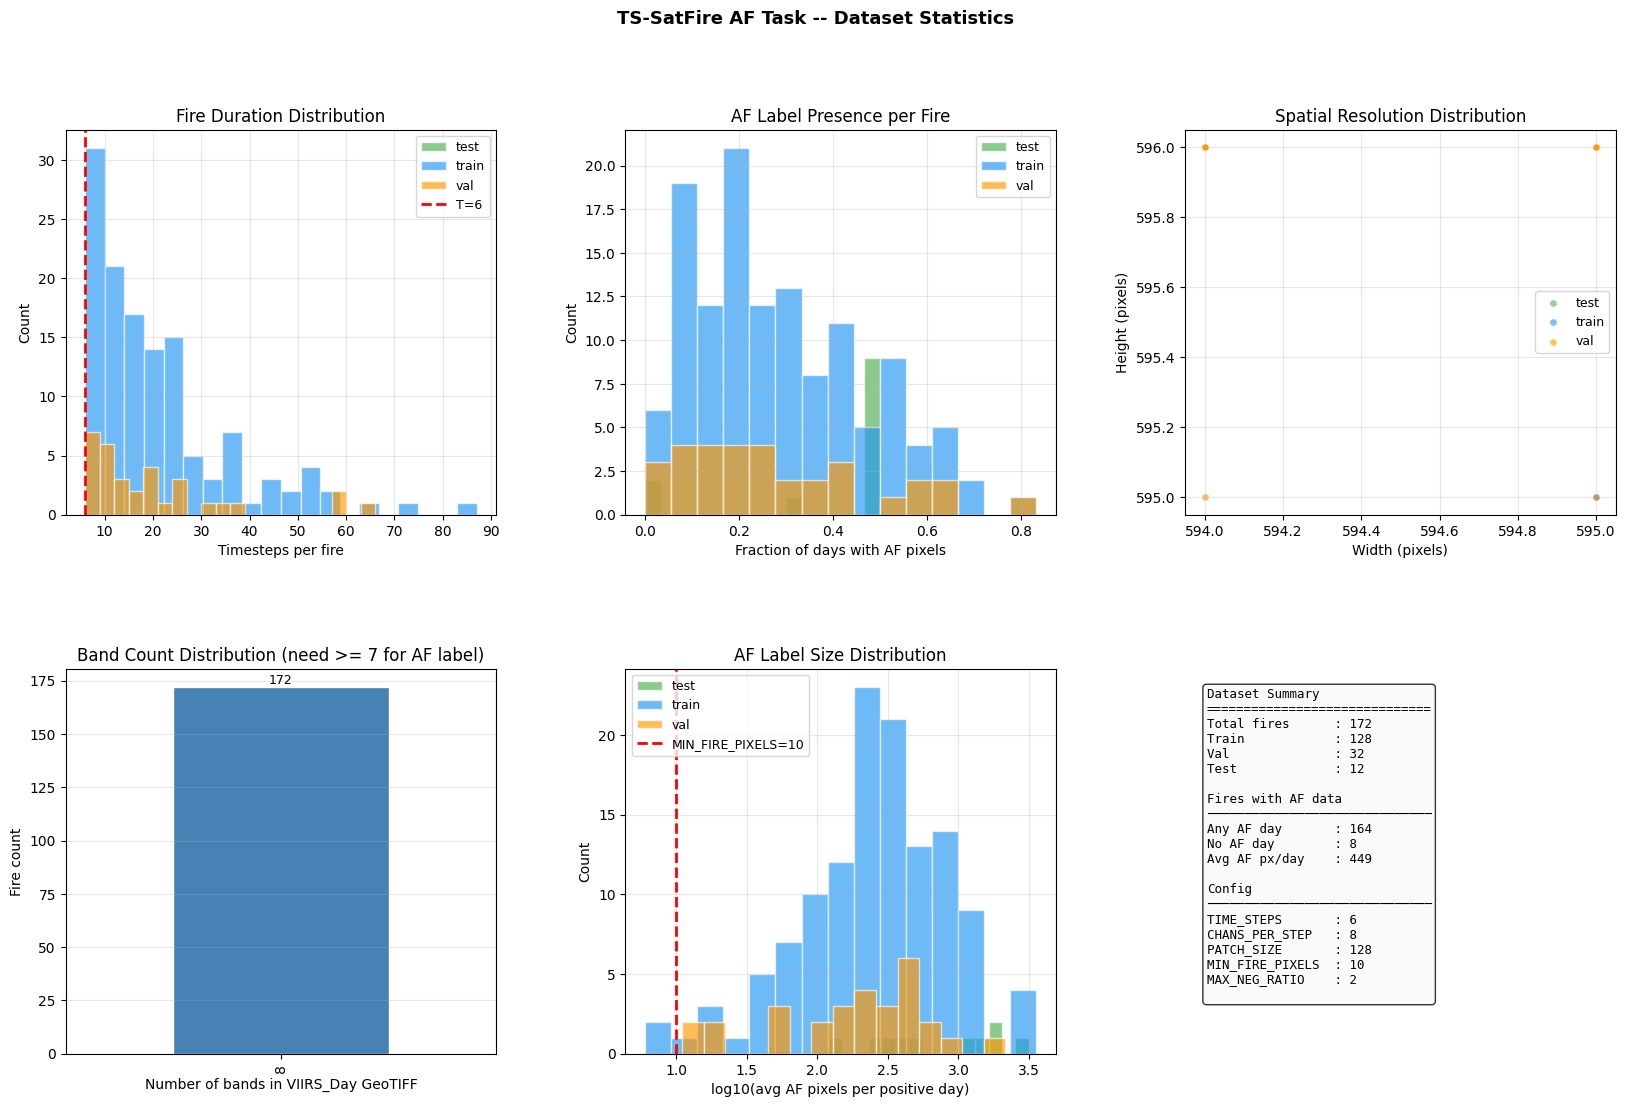

EDA complete.


In [5]:
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

# 1. Fire duration distribution
ax1 = fig.add_subplot(gs[0, 0])
for split, grp in df.groupby('split'):
    ax1.hist(grp['n_days'], bins=20, alpha=0.65,
             color=colors[split], label=split, edgecolor='white')
ax1.axvline(TIME_STEPS, color='red', lw=2, ls='--', label=f'T={TIME_STEPS}')
ax1.set_xlabel('Timesteps per fire')
ax1.set_ylabel('Count')
ax1.set_title('Fire Duration Distribution')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. AF days fraction per fire
ax2 = fig.add_subplot(gs[0, 1])
df['af_frac'] = df['n_af_days'] / df['n_days'].clip(lower=1)
for split, grp in df.groupby('split'):
    ax2.hist(grp['af_frac'], bins=15, alpha=0.65,
             color=colors[split], label=split, edgecolor='white')
ax2.set_xlabel('Fraction of days with AF pixels')
ax2.set_ylabel('Count')
ax2.set_title('AF Label Presence per Fire')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Spatial resolution scatter
ax3 = fig.add_subplot(gs[0, 2])
for split, grp in df.groupby('split'):
    ax3.scatter(grp['width'], grp['height'], alpha=0.6,
                color=colors[split], label=split, s=30, edgecolors='white')
ax3.set_xlabel('Width (pixels)')
ax3.set_ylabel('Height (pixels)')
ax3.set_title('Spatial Resolution Distribution')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Band count
ax4 = fig.add_subplot(gs[1, 0])
df['n_bands'].value_counts().sort_index().plot(kind='bar', ax=ax4,
    color='steelblue', edgecolor='white')
ax4.set_xlabel('Number of bands in VIIRS_Day GeoTIFF')
ax4.set_ylabel('Fire count')
ax4.set_title('Band Count Distribution (need >= 7 for AF label)')
ax4.axvline(0, color='red', lw=0)  # placeholder
for p in ax4.patches:
    ax4.annotate(str(int(p.get_height())),
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

# 5. Average AF pixel count per fire
ax5 = fig.add_subplot(gs[1, 1])
df_has_af = df[df['avg_af_px'] > 0]
for split, grp in df_has_af.groupby('split'):
    ax5.hist(np.log10(grp['avg_af_px'] + 1), bins=15, alpha=0.65,
             color=colors[split], label=split, edgecolor='white')
ax5.axvline(np.log10(MIN_FIRE_PIXELS), color='red', lw=2, ls='--',
             label=f'MIN_FIRE_PIXELS={MIN_FIRE_PIXELS}')
ax5.set_xlabel('log10(avg AF pixels per positive day)')
ax5.set_ylabel('Count')
ax5.set_title('AF Label Size Distribution')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 6. Summary stats text
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary = (
    f'Dataset Summary\n'
    f'{"="*30}\n'
    f'Total fires      : {len(df)}\n'
    f'Train            : {len(train_fires)}\n'
    f'Val              : {len(val_fires)}\n'
    f'Test             : {len(test_fires)}\n'
    f'\n'
    f'Fires with AF data\n'
    f'{"─"*30}\n'
    f'Any AF day       : {(df.n_af_days > 0).sum()}\n'
    f'No AF day        : {(df.n_af_days == 0).sum()}\n'
    f'Avg AF px/day    : {df.avg_af_px.mean():.0f}\n'
    f'\n'
    f'Config\n'
    f'{"─"*30}\n'
    f'TIME_STEPS       : {TIME_STEPS}\n'
    f'CHANS_PER_STEP   : {CHANS_PER_STEP}\n'
    f'PATCH_SIZE       : {PATCH_SIZE}\n'
    f'MIN_FIRE_PIXELS  : {MIN_FIRE_PIXELS}\n'
    f'MAX_NEG_RATIO    : {MAX_NEG_RATIO}\n'
)
ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

plt.suptitle('TS-SatFire AF Task -- Dataset Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR, 'eda_af_v1.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete.')

## Normalisation statistics

Two-pass percentile-clip pipeline on CHANS_PER_STEP=8 channels
(6 spectral day + 2 night). Auxiliary data is NOT used for AF
following the paper's temporal model setup (T4Fire, GRU, LSTM all
use spectral bands only).

In [6]:
CHAN_NAMES = ['I1 (Red)', 'I2 (NIR)', 'I3 (SWIR)', 'I4 (MIR day)',
              'I5 (LWIR day)', 'M11 (SWIR2)', 'I4 Night', 'I5 Night']

def load_frame_af(fd, day_path, return_label=False):
    """Load 8-channel frame for AF task: 6 spectral day + 2 night.

    If return_label=True, also returns the AF binary label derived from
    band 7 of the day file (VNP14IMG fire mask, values >= 7 = fire).
    This avoids a second rasterio.open call for the label in __getitem__.
    """
    date_str   = os.path.basename(day_path).replace('_VIIRS_Day.tif', '')
    night_path = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
    with rasterio.open(day_path) as src:
        day_arr = src.read().astype(np.float32)
    spectral = day_arr[:6]  # bands I1-I5, M11
    H, W = spectral.shape[1], spectral.shape[2]
    if os.path.exists(night_path):
        with rasterio.open(night_path) as src:
            night = src.read().astype(np.float32)[:2, :H, :W]
    else:
        night = np.full((2, H, W), np.nan, np.float32)
    frame = np.concatenate([spectral, night], axis=0)  # (8, H, W)
    if return_label:
        # Band 7 (index 6) is VNP14IMG fire mask
        if day_arr.shape[0] >= 7:
            label = (day_arr[6] >= 7).astype(np.float32)
        else:
            label = np.zeros((H, W), np.float32)
        return frame, label
    return frame


def compute_norm_stats_af(fire_dirs, n_fires=30, n_days=4, seed=SEED,
                           clip_percentile=99):
    rng    = random.Random(seed)
    sample = rng.sample(fire_dirs, min(n_fires, len(fire_dirs)))

    all_vals = [[] for _ in range(CHANS_PER_STEP)]
    for fd in tqdm(sample, desc='Pass 1 / percentiles'):
        day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
        for dp in random.sample(day_files, min(n_days, len(day_files))):
            try:
                frame = load_frame_af(fd, dp)
                for c in range(CHANS_PER_STEP):
                    v = frame[c][np.isfinite(frame[c])].ravel()
                    if v.size > 0:
                        all_vals[c].append(v[::max(1, len(v)//2000)])
            except Exception:
                pass

    lo_bounds = np.zeros(CHANS_PER_STEP, np.float32)
    hi_bounds = np.zeros(CHANS_PER_STEP, np.float32)
    for c in range(CHANS_PER_STEP):
        if all_vals[c]:
            v = np.concatenate(all_vals[c])
            lo_bounds[c] = np.percentile(v, 100 - clip_percentile)
            hi_bounds[c] = np.percentile(v, clip_percentile)

    sums    = np.zeros(CHANS_PER_STEP, np.float64)
    sq_sums = np.zeros(CHANS_PER_STEP, np.float64)
    counts  = np.zeros(CHANS_PER_STEP, np.float64)
    for fd in tqdm(sample, desc='Pass 2 / mean+std'):
        day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
        for dp in random.sample(day_files, min(n_days, len(day_files))):
            try:
                frame = load_frame_af(fd, dp)
                for c in range(CHANS_PER_STEP):
                    v = frame[c][np.isfinite(frame[c])]
                    v = np.clip(v, lo_bounds[c], hi_bounds[c])
                    sums[c]    += v.sum()
                    sq_sums[c] += (v**2).sum()
                    counts[c]  += len(v)
            except Exception:
                pass

    means = (sums   / counts.clip(min=1)).astype(np.float32)
    stds  = np.sqrt(sq_sums / counts.clip(min=1) - means**2).astype(np.float32)
    stds  = np.where(stds < 1e-6, 1.0, stds)
    return means, stds, lo_bounds, hi_bounds


# Load or compute
resume_stats = None
if RESUME_WEIGHTS_DIR:
    resume_stats = os.path.join(RESUME_WEIGHTS_DIR, 'norm_stats_af_v1.npz')

if resume_stats and os.path.exists(resume_stats):
    data = np.load(resume_stats)
    CHAN_MEANS, CHAN_STDS, CLIP_LO, CLIP_HI = \
        data['means'], data['stds'], data['clip_lo'], data['clip_hi']
    import shutil; shutil.copy(resume_stats, STATS_PATH)
    print(f'Loaded norm stats from {resume_stats}')
else:
    CHAN_MEANS, CHAN_STDS, CLIP_LO, CLIP_HI = \
        compute_norm_stats_af(train_fires)
    np.savez(STATS_PATH, means=CHAN_MEANS, stds=CHAN_STDS,
             clip_lo=CLIP_LO, clip_hi=CLIP_HI)
    print(f'Saved norm stats to {STATS_PATH}')

print(f'\nNormalisation statistics ({CHANS_PER_STEP} channels):')
print(f'{"Chan":<5} {"Name":<18} {"Mean":>10} {"Std":>10} {"ClipLo":>10} {"ClipHi":>10}')
print('-' * 65)
for c in range(CHANS_PER_STEP):
    print(f'{c:<5} {CHAN_NAMES[c]:<18} {CHAN_MEANS[c]:>10.3f} {CHAN_STDS[c]:>10.3f} '
          f'{CLIP_LO[c]:>10.3f} {CLIP_HI[c]:>10.3f}')

Pass 1 / percentiles:   0%|          | 0/30 [00:00<?, ?it/s]

Pass 2 / mean+std:   0%|          | 0/30 [00:00<?, ?it/s]

Saved norm stats to /kaggle/working/norm_stats_af_v1.npz

Normalisation statistics (8 channels):
Chan  Name                     Mean        Std     ClipLo     ClipHi
-----------------------------------------------------------------
0     I1 (Red)               17.146     14.468      2.635     76.556
1     I2 (NIR)               25.592     14.209      1.733     83.046
2     I3 (SWIR)              21.276     10.634      0.598     53.719
3     I4 (MIR day)          309.870     13.301    271.539    334.931
4     I5 (LWIR day)         298.432     17.684    239.435    325.237
5     M11 (SWIR2)            15.205      9.215      0.346     43.813
6     I4 Night              281.805     10.782    226.871    296.233
7     I5 Night              280.759     12.221    219.131    295.576


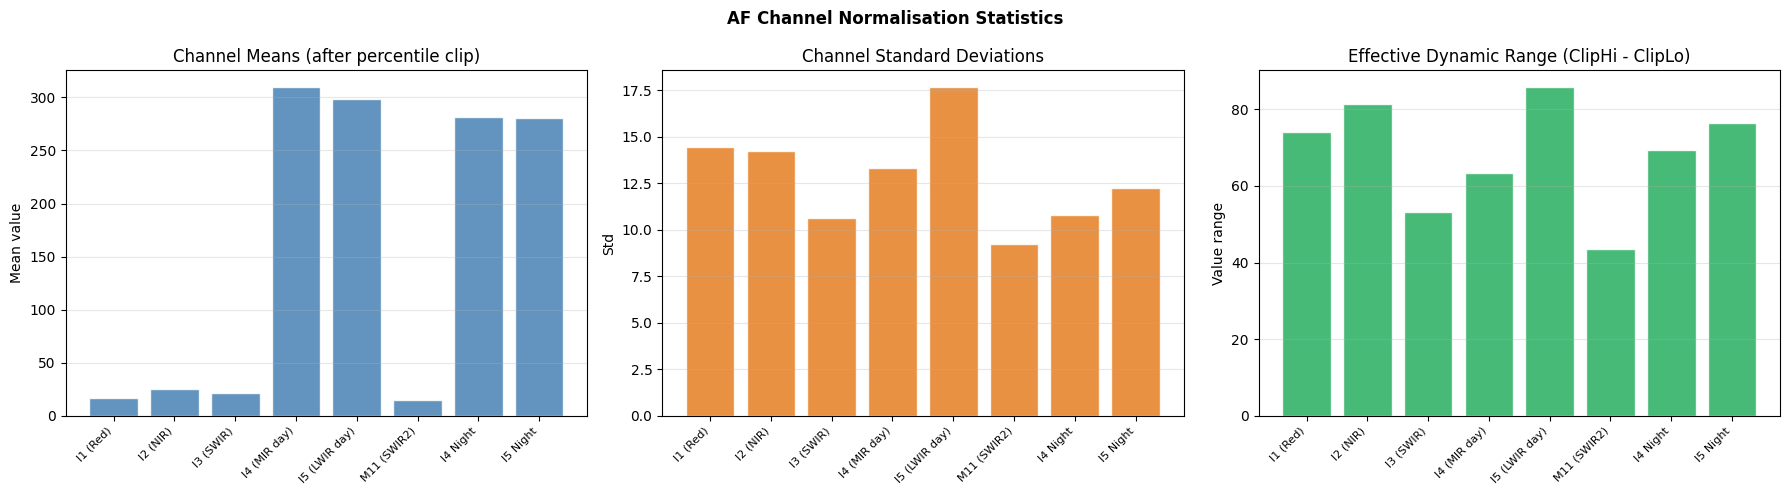

In [7]:
# Normalisation statistics diagnostic plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_pos = range(CHANS_PER_STEP)
axes[0].bar(x_pos, CHAN_MEANS, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(CHAN_NAMES, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Channel Means (after percentile clip)')
axes[0].set_ylabel('Mean value')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x_pos, CHAN_STDS, color='#e67e22', edgecolor='white', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(CHAN_NAMES, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Channel Standard Deviations')
axes[1].set_ylabel('Std')
axes[1].grid(True, alpha=0.3, axis='y')

# Dynamic range: clip_hi - clip_lo
dyn_range = CLIP_HI - CLIP_LO
axes[2].bar(x_pos, dyn_range, color='#27ae60', edgecolor='white', alpha=0.85)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(CHAN_NAMES, rotation=45, ha='right', fontsize=8)
axes[2].set_title('Effective Dynamic Range (ClipHi - ClipLo)')
axes[2].set_ylabel('Value range')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('AF Channel Normalisation Statistics', fontsize=12, fontweight='bold')
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR, 'norm_stats_af_v1.png'), dpi=150, bbox_inches='tight')
plt.show()

## Dataset class

Key differences from BA dataset:
- Loads 8 channels (spectral only, no aux)
- Label is band 7 of VIIRS_Day (VNP14IMG fire mask, values >= 7)
- H/V flip augmentation enabled for training
- No thermal cummax preprocessing (AF needs the instantaneous signal, not cumulative)

In [8]:
class AFDataset(Dataset):

    def __init__(self, fire_dirs, time_steps=TIME_STEPS,
                 interval=1, patch_size=PATCH_SIZE,
                 means=None, stds=None,
                 clip_lo=None, clip_hi=None,
                 augment=False):
        self.T          = time_steps
        self.interval   = interval
        self.patch_size = patch_size
        self.means      = means
        self.stds       = stds
        self.clip_lo    = clip_lo
        self.clip_hi    = clip_hi
        self.augment    = augment
        self.samples    = []
        self._build_index(fire_dirs)

    def _build_index(self, fire_dirs):
        n_pos = n_neg = n_neg_kept = skipped = 0
        rng = random.Random(SEED)

        for fd in fire_dirs:
            day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
            if len(day_files) < self.T:
                skipped += 1
                continue

            # Check band count -- need >= 7 for AF label
            try:
                with rasterio.open(day_files[0]) as src:
                    if src.count < 7:
                        skipped += 1
                        continue
            except Exception:
                skipped += 1
                continue

            n = len(day_files)
            start = 0
            while start + self.T <= n:
                last_day = day_files[start + self.T - 1]
                lbl      = get_af_label_from_day(last_day)

                if lbl is None:
                    start += self.interval
                    continue

                if self.patch_size:
                    H, W = lbl.shape
                    if H > self.patch_size and W > self.patch_size:
                        r0 = (H - self.patch_size) // 2
                        c0 = (W - self.patch_size) // 2
                        p  = self.patch_size
                        lbl = lbl[r0:r0+p, c0:c0+p]

                fire_px    = int(lbl.sum())
                is_positive = fire_px >= MIN_FIRE_PIXELS

                if is_positive:
                    n_pos += 1
                    keep = True
                else:
                    n_neg += 1
                    keep = rng.random() < 1.0 / (MAX_NEG_RATIO + 1)
                    if keep:
                        n_neg_kept += 1

                if keep:
                    self.samples.append({
                        'fire_dir'  : fd,
                        'day_files' : day_files,
                        'start'     : start,
                        'end'       : start + self.T - 1,
                    })
                start += self.interval

        print(f'AFDataset: {len(self.samples)} samples '
              f'(T={self.T}, interval={self.interval}, skipped={skipped})')
        print(f'  positive patches : {n_pos}')
        print(f'  neg kept/total   : {n_neg_kept}/{n_neg}')

    @staticmethod
    def _date(path):
        return os.path.basename(path).replace('_VIIRS_Day.tif', '')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s         = self.samples[idx]
        fd        = s['fire_dir']
        win_files = s['day_files'][s['start'] : s['end'] + 1]

        # Load each timestep -- last file also returns the AF label.
        # This eliminates the old shapes-loop (6 rasterio opens) and the
        # separate get_af_label_from_day call (1 redundant re-open).
        # Total opens per sample: T*2 (day + night per timestep) -- unavoidable.
        frames = []
        H = W = None
        for t, dp in enumerate(win_files):
            is_last = (t == len(win_files) - 1)
            if is_last:
                frame, label = load_frame_af(fd, dp, return_label=True)
            else:
                frame = load_frame_af(fd, dp, return_label=False)
            if H is None:
                H, W = frame.shape[1], frame.shape[2]
            frames.append(frame[:, :H, :W])

        label = label[:H, :W]
        stack = np.stack(frames, axis=0)  # (T, 8, H, W)

        # Normalise
        if self.clip_lo is not None:
            stack = np.clip(stack,
                            self.clip_lo[None, :, None, None],
                            self.clip_hi[None, :, None, None])
        if self.means is not None:
            stack = (stack - self.means[None, :, None, None]) / \
                     self.stds[ None, :, None, None]
        stack = np.nan_to_num(stack, nan=0.0, posinf=0.0, neginf=0.0)

        # Centre crop to patch_size
        if self.patch_size and H > self.patch_size and W > self.patch_size:
            r0 = (H - self.patch_size) // 2
            c0 = (W - self.patch_size) // 2
            p  = self.patch_size
            stack = stack[:, :, r0:r0+p, c0:c0+p]
            label = label[r0:r0+p, c0:c0+p]

        # Augmentation: H-flip and V-flip (only during training)
        if self.augment:
            if random.random() > 0.5:
                stack = np.flip(stack, axis=-1).copy()   # horizontal flip
                label = np.flip(label, axis=-1).copy()
            if random.random() > 0.5:
                stack = np.flip(stack, axis=-2).copy()   # vertical flip
                label = np.flip(label, axis=-2).copy()

        # x shape: (C, T, H, W) -- channels first, time second
        x = torch.from_numpy(stack.transpose(1, 0, 2, 3).copy()).float()
        y = torch.from_numpy(label.copy()).long()
        return x, y


print('AFDataset defined.')

AFDataset defined.


## DataLoaders and sanity checks

In [9]:
train_ds = AFDataset(
    fire_dirs  = train_fires,
    time_steps = TIME_STEPS,
    interval   = TRAIN_INTERVAL,
    patch_size = PATCH_SIZE,
    means=CHAN_MEANS, stds=CHAN_STDS, clip_lo=CLIP_LO, clip_hi=CLIP_HI,
    augment    = True,
)
val_ds = AFDataset(
    fire_dirs  = val_fires,
    time_steps = TIME_STEPS,
    interval   = VAL_INTERVAL,
    patch_size = PATCH_SIZE,
    means=CHAN_MEANS, stds=CHAN_STDS, clip_lo=CLIP_LO, clip_hi=CLIP_HI,
    augment    = False,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True,
                          persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True,
                          persistent_workers=True)

print(f'Train batches / epoch : {len(train_loader)}')
print(f'Val   batches / epoch : {len(val_loader)}')

xb, yb = next(iter(train_loader))
print(f'\nBatch x : {tuple(xb.shape)}  expect (N={BATCH_SIZE}, C={CHANS_PER_STEP}, T={TIME_STEPS}, H={PATCH_SIZE}, W={PATCH_SIZE})')
print(f'Batch y : {tuple(yb.shape)}  expect (N={BATCH_SIZE}, H={PATCH_SIZE}, W={PATCH_SIZE})')
print(f'y unique values : {yb.unique().tolist()}  expect [0, 1]')
fire_frac = (yb == 1).float().mean().item()
print(f'Fire pixel fraction in first batch : {fire_frac:.4f}')

pos_count = 0
for i, (xb, yb) in enumerate(train_loader):
    if i >= 10: break
    if (yb == 1).any(): pos_count += 1
print(f'Batches with fire pixels in first 10 : {pos_count}/10  (expect > 5)')

AFDataset: 1733 samples (T=6, interval=1, skipped=0)
  positive patches : 1519
  neg kept/total   : 214/612
AFDataset: 138 samples (T=6, interval=3, skipped=0)
  positive patches : 116
  neg kept/total   : 22/54
Train batches / epoch : 288
Val   batches / epoch : 23

Batch x : (6, 8, 6, 128, 128)  expect (N=6, C=8, T=6, H=128, W=128)
Batch y : (6, 128, 128)  expect (N=6, H=128, W=128)
y unique values : [0, 1]  expect [0, 1]
Fire pixel fraction in first batch : 0.0132
Batches with fire pixels in first 10 : 10/10  (expect > 5)


Label density scan:   0%|          | 0/200 [00:00<?, ?it/s]


Label density across 200 samples:
  Mean fire fraction  : 0.0184
  Median fire fraction: 0.0076
  Fraction > 0        : 0.8900
  Fraction > 0.01     : 0.4300
  Max fire fraction   : 0.2912


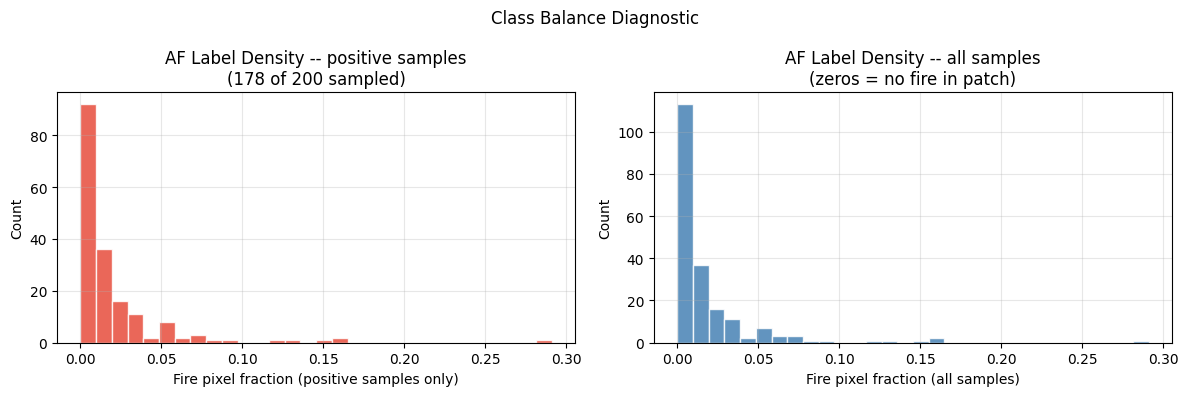

In [10]:
# Label density diagnostic: sample 200 training items and plot distribution
fire_fracs = []
sample_indices = random.sample(range(len(train_ds)), min(200, len(train_ds)))
for idx in tqdm(sample_indices, desc='Label density scan', leave=False):
    _, y = train_ds[idx]
    fire_fracs.append((y == 1).float().mean().item())

fire_fracs = np.array(fire_fracs)
print(f'\nLabel density across 200 samples:')
print(f'  Mean fire fraction  : {fire_fracs.mean():.4f}')
print(f'  Median fire fraction: {np.median(fire_fracs):.4f}')
print(f'  Fraction > 0        : {(fire_fracs > 0).mean():.4f}')
print(f'  Fraction > 0.01     : {(fire_fracs > 0.01).mean():.4f}')
print(f'  Max fire fraction   : {fire_fracs.max():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(fire_fracs[fire_fracs > 0], bins=30,
             color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Fire pixel fraction (positive samples only)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'AF Label Density -- positive samples\n'
                   f'({(fire_fracs>0).sum()} of {len(fire_fracs)} sampled)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(fire_fracs, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Fire pixel fraction (all samples)')
axes[1].set_ylabel('Count')
axes[1].set_title('AF Label Density -- all samples\n'
                   f'(zeros = no fire in patch)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Class Balance Diagnostic', fontsize=12)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR, 'label_density_af_v1.png'), dpi=150, bbox_inches='tight')
plt.show()

## Model -- Hybrid CNN-Transformer

### Architecture design

```
Input: (N, C=8, T=6, H, W)
       |
       | reshape to (N*T, C, H, W) -- process each timestep independently
       |
  [Shared CNN Encoder]  -- 4 levels, weights tied across T
  enc1: (N*T,  48, H,    W   )  DoubleConv2D
  enc2: (N*T,  96, H/2,  W/2 )  DoubleConv2D + MaxPool
  enc3: (N*T, 192, H/4,  W/4 )  DoubleConv2D + MaxPool
  enc4: (N*T, 384, H/8,  W/8 )  DoubleConv2D + MaxPool
       |
       | reshape to (N, T, 384, H/8, W/8)
       | avg-pool spatial to (N, T, 384, 1, 1) -- sequence of vectors
       | squeeze to (N, T, 384)
       |
  [Bottleneck Temporal Transformer]  -- 4 layers, 4 heads
  Self-attention across T=6 timesteps
  Output: (N, T, 384)
       |
       | select last timestep: (N, 384)
       | unsqueeze spatial: (N, 384, H/8, W/8)
       |
  [CNN Decoder]  -- 4 levels with skip connections from encoder
  dec4: (N, 192, H/4,  W/4 )  Upsample + DoubleConv2D
  dec3: (N,  96, H/2,  W/2 )  Upsample + DoubleConv2D
  dec2: (N,  48, H,    W   )  Upsample + DoubleConv2D
  dec1: (N,  48, H,    W   )  DoubleConv2D
       |
  head: (N, 2, H, W)  -- 1x1 conv, 2-class logits
```

The skip connections come from the *last timestep's* encoder features, which is
the timestep the label corresponds to.

In [11]:
class DoubleConv2D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class TemporalTransformer(nn.Module):
    """
    Standard Transformer encoder applied across the time axis.
    Input : (N, T, d_model)
    Output: (N, T, d_model)
    """
    def __init__(self, d_model, n_heads, n_layers, ff_dim, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = ff_dim,
            dropout         = dropout,
            batch_first     = True,   # (N, T, d_model)
            norm_first      = True,   # Pre-LN for training stability
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers,
            norm=nn.LayerNorm(d_model)
        )
        # Learnable positional encoding
        self.pos_embed = nn.Parameter(torch.zeros(1, TIME_STEPS, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        x = x + self.pos_embed[:, :x.shape[1], :]
        return self.transformer(x)


class HybridAFNet(nn.Module):
    """
    Hybrid CNN-Transformer for Active Fire Detection.

    Input  : (N, C, T, H, W)  where C=CHANS_PER_STEP=8, T=TIME_STEPS=6
    Output : (N, 2, H, W)     2-class logits for the last timestep

    Architecture:
      Shared CNN encoder (weights tied across T) -> 4 levels of features
      Bottleneck Temporal Transformer (attention across T on global-avg-pooled features)
      CNN decoder with skip connections from last timestep encoder features

    Skip connection levels (corrected):
      fused  (b*8, H/8) --up--> (b*8, H/4)  cat e3_last(b*4, H/4) -> dec4 -> (b*4, H/4)
      dec4   (b*4, H/4) --up--> (b*4, H/2)  cat e2_last(b*2, H/2) -> dec3 -> (b*2, H/2)
      dec3   (b*2, H/2) --up--> (b*2, H  )  cat e1_last(b,   H  ) -> dec2 -> (b,   H  )
      dec2   (b,   H  )                                             -> dec1 -> (b,   H  )
      head: 1x1 conv -> (2, H, W)
    """
    def __init__(self, in_ch=CHANS_PER_STEP, base_ch=BASE_CH,
                 n_heads=N_HEADS, n_layers=N_TRANS_LAYERS,
                 ff_dim=TRANS_FF_DIM, dropout=TRANS_DROPOUT,
                 n_classes=2):
        super().__init__()
        b = base_ch  # 48

        # Shared 2D CNN encoder
        self.enc1 = DoubleConv2D(in_ch, b,    dropout=0.0)   # -> (b,   H,   W  )
        self.enc2 = DoubleConv2D(b,    b*2,   dropout=0.0)   # -> (b*2, H/2, W/2)
        self.enc3 = DoubleConv2D(b*2,  b*4,   dropout=0.1)   # -> (b*4, H/4, W/4)
        self.enc4 = DoubleConv2D(b*4,  b*8,   dropout=0.1)   # -> (b*8, H/8, W/8)
        self.pool = nn.MaxPool2d(2, 2)

        d_model = b * 8  # 384 -- bottleneck feature dim

        # Temporal transformer
        self.temporal = TemporalTransformer(
            d_model=d_model, n_heads=n_heads,
            n_layers=n_layers, ff_dim=ff_dim, dropout=dropout
        )

        # Projection from transformer output
        self.proj = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(inplace=True),
        )

        # CNN decoder with corrected skip connection channel counts:
        #   dec4 in : b*8 (from fused, upsampled) + b*4 (from e3_last) = b*12
        #   dec3 in : b*4 (from dec4)              + b*2 (from e2_last) = b*6
        #   dec2 in : b*2 (from dec3)              + b   (from e1_last) = b*3
        #   dec1 in : b   (from dec2)                                    = b
        self.up4  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec4 = DoubleConv2D(b*8 + b*4, b*4, dropout=0.1)

        self.up3  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec3 = DoubleConv2D(b*4 + b*2, b*2, dropout=0.1)

        self.up2  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2 = DoubleConv2D(b*2 + b,   b,   dropout=0.0)

        self.dec1 = DoubleConv2D(b,          b,   dropout=0.0)

        self.head = nn.Conv2d(b, n_classes, 1)

    def forward(self, x):
        # x: (N, C, T, H, W)
        N, C, T, H, W = x.shape

        # --- Shared CNN encoder ---
        # Reshape (N, C, T, H, W) -> (N*T, C, H, W) to process all timesteps at once
        x_flat = x.permute(0, 2, 1, 3, 4).reshape(N * T, C, H, W)

        e1_flat = self.enc1(x_flat)              # (N*T, b,   H,   W  )
        e2_flat = self.enc2(self.pool(e1_flat))  # (N*T, b*2, H/2, W/2)
        e3_flat = self.enc3(self.pool(e2_flat))  # (N*T, b*4, H/4, W/4)
        e4_flat = self.enc4(self.pool(e3_flat))  # (N*T, b*8, H/8, W/8)

        # Extract last timestep encoder features for skip connections
        # Items at positions T-1, 2T-1, 3T-1, ... in the flat batch
        last_idx = torch.arange(T - 1, N * T, T, device=x.device)  # length N
        e1_last = e1_flat[last_idx]  # (N, b,   H,   W  )
        e2_last = e2_flat[last_idx]  # (N, b*2, H/2, W/2)
        e3_last = e3_flat[last_idx]  # (N, b*4, H/4, W/4)
        e4_last = e4_flat[last_idx]  # (N, b*8, H/8, W/8)  -- used for fused base only

        # --- Temporal Transformer ---
        # Global avg pool e4 to get a feature vector per timestep: (N*T, b*8) -> (N, T, b*8)
        seq = e4_flat.mean(dim=[2, 3])          # (N*T, b*8)
        seq = seq.reshape(N, T, -1)             # (N, T, b*8)

        seq_out = self.temporal(seq)            # (N, T, b*8)
        ctx     = seq_out[:, -1, :]             # (N, b*8)  -- last timestep context
        ctx     = self.proj(ctx)                # (N, b*8)

        # Broadcast context vector to spatial dims of e4_last and fuse via addition
        ctx_spatial = ctx.unsqueeze(-1).unsqueeze(-1).expand_as(e4_last)  # (N, b*8, H/8, W/8)
        fused = e4_last + ctx_spatial           # (N, b*8, H/8, W/8)

        # --- CNN Decoder (corrected skip levels) ---
        # up4: (N, b*8, H/8) -> (N, b*8, H/4),  cat e3_last(N, b*4, H/4)
        d4 = self.dec4(torch.cat([self.up4(fused), e3_last], dim=1))  # (N, b*4, H/4, W/4)

        # up3: (N, b*4, H/4) -> (N, b*4, H/2),  cat e2_last(N, b*2, H/2)
        d3 = self.dec3(torch.cat([self.up3(d4),    e2_last], dim=1))  # (N, b*2, H/2, W/2)

        # up2: (N, b*2, H/2) -> (N, b*2, H  ),  cat e1_last(N, b,   H  )
        d2 = self.dec2(torch.cat([self.up2(d3),    e1_last], dim=1))  # (N, b,   H,   W  )

        d1 = self.dec1(d2)                      # (N, b, H, W)

        return self.head(d1)                    # (N, 2, H, W)


model = HybridAFNet(
    in_ch=CHANS_PER_STEP, base_ch=BASE_CH,
    n_heads=N_HEADS, n_layers=N_TRANS_LAYERS,
    ff_dim=TRANS_FF_DIM, dropout=TRANS_DROPOUT
)

if torch.cuda.device_count() > 1:
    print(f'Using DataParallel across {torch.cuda.device_count()} GPUs')
    model = nn.DataParallel(model)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'HybridAFNet total parameters : {n_params:,}  ({n_params/1e6:.2f}M)')


Using DataParallel across 2 GPUs
HybridAFNet total parameters : 8,523,682  (8.52M)


## Model architecture diagnostic

Full layer-by-layer parameter breakdown and forward-pass shape trace.

In [12]:
def print_model_summary(model):
    lines = []
    lines.append('=' * 90)
    lines.append('HybridAFNet v1 -- Architecture Summary')
    lines.append('=' * 90)
    lines.append(f'Input  : (N, C={CHANS_PER_STEP}, T={TIME_STEPS}, H, W)')
    lines.append(f'Output : (N, 2, H, W) -- 2-class logits for last timestep')
    lines.append('')

    total = 0
    section_totals = {}
    current_section = ''

    lines.append(f'{"Layer":<50} {"Type":<22} {"Params":>12} {"Weight shape"}')
    lines.append('-' * 100)

    m = model.module if hasattr(model, 'module') else model
    for name, module in m.named_modules():
        if list(module.children()): continue
        params = sum(p.numel() for p in module.parameters())
        if params == 0: continue

        section = name.split('.')[0]
        if section != current_section:
            if current_section in section_totals:
                lines.append(f'  >> {current_section} subtotal : {section_totals[current_section]:,}')
                lines.append('')
            current_section = section
        section_totals[section] = section_totals.get(section, 0) + params

        shape_str = ''
        for pname, p in module.named_parameters():
            if pname == 'weight':
                shape_str = str(tuple(p.shape))
                break
        mtype = type(module).__name__
        lines.append(f'{name:<50} {mtype:<22} {params:>12,} {shape_str}')
        total += params

    if current_section in section_totals:
        lines.append(f'  >> {current_section} subtotal : {section_totals[current_section]:,}')

    lines.append('')
    lines.append('=' * 90)
    lines.append(f'TOTAL : {total:,}  ({total/1e6:.3f}M)')
    lines.append('')
    lines.append('Section breakdown:')
    lines.append(f'{"Section":<20} {"Params":>12} {"% total":>10}')
    lines.append('-' * 44)
    for sec, cnt in section_totals.items():
        lines.append(f'{sec:<20} {cnt:>12,} {100*cnt/total:>9.1f}%')

    lines.append('')
    lines.append('Component roles:')
    enc_params = sum(section_totals.get(s, 0) for s in ['enc1','enc2','enc3','enc4'])
    dec_params = sum(section_totals.get(s, 0) for s in ['dec1','dec2','dec3','dec4'])
    trans_params = section_totals.get('temporal', 0)
    lines.append(f'  CNN encoder (spatial feature extraction) : {enc_params:,}  ({100*enc_params/total:.1f}%)')
    lines.append(f'  Temporal Transformer (time reasoning)    : {trans_params:,}  ({100*trans_params/total:.1f}%)')
    lines.append(f'  CNN decoder (spatial reconstruction)     : {dec_params:,}  ({100*dec_params/total:.1f}%)')
    lines.append('=' * 90)

    return '\n'.join(lines)


summary_text = print_model_summary(model)
print(summary_text)

with open(os.path.join(OUTPUT_DIR, 'model_summary_af_v1.txt'), 'w') as f:
    f.write(summary_text)

# Forward pass shape check
print('\nForward pass shape check:')
m_check = model.module if hasattr(model, 'module') else model
with torch.no_grad():
    dummy = torch.zeros(2, CHANS_PER_STEP, TIME_STEPS, PATCH_SIZE, PATCH_SIZE).to(device)
    out   = model(dummy)
    print(f'  Input  : {tuple(dummy.shape)}')
    print(f'  Output : {tuple(out.shape)}  expect (2, 2, {PATCH_SIZE}, {PATCH_SIZE})')
    assert out.shape == (2, 2, PATCH_SIZE, PATCH_SIZE), 'Shape mismatch!'
print('Shape check passed.')

HybridAFNet v1 -- Architecture Summary
Input  : (N, C=8, T=6, H, W)
Output : (N, 2, H, W) -- 2-class logits for last timestep

Layer                                              Type                         Params Weight shape
----------------------------------------------------------------------------------------------------
enc1.block.0                                       Conv2d                        3,456 (48, 8, 3, 3)
enc1.block.1                                       BatchNorm2d                      96 (48,)
enc1.block.3                                       Conv2d                       20,736 (48, 48, 3, 3)
enc1.block.4                                       BatchNorm2d                      96 (48,)
  >> enc1 subtotal : 24,384

enc2.block.0                                       Conv2d                       41,472 (96, 48, 3, 3)
enc2.block.1                                       BatchNorm2d                     192 (96,)
enc2.block.3                                       Conv2d  

## Loss and metrics

**DiceCE loss**: 0.5 * SoftDice + 0.5 * CrossEntropy.
- Dice component handles class imbalance
- CE component provides stable per-pixel gradients that help escape early training plateaus
- CE fire class weight upweights the minority fire class in the CE term

In [13]:
class DiceCELoss(nn.Module):
    def __init__(self, dice_w=DICE_WEIGHT, ce_w=CE_WEIGHT,
                 ce_fire_weight=CE_FIRE_WEIGHT, smooth=1.0):
        super().__init__()
        self.dice_w          = dice_w
        self.ce_w            = ce_w
        self.smooth          = smooth
        self.ce_fire_weight  = ce_fire_weight
        # Do NOT store the weight tensor here -- it must be created on the
        # correct device at forward time, otherwise DataParallel / .to(device)
        # moves the model but leaves the weight on CPU.

    def forward(self, logits, targets):
        # logits  : (N, 2, H, W)
        # targets : (N, H, W) long
        probs = torch.softmax(logits, dim=1)[:, 1]
        tgt   = targets.float()
        inter = (probs * tgt).sum()
        union = probs.sum() + tgt.sum()
        dice_loss = 1.0 - (2.0 * inter + self.smooth) / (union + self.smooth)

        # Create the weight tensor on the same device as logits at runtime
        weight = torch.tensor([1.0, self.ce_fire_weight], device=logits.device)
        ce_loss = F.cross_entropy(logits, targets, weight=weight)

        return self.dice_w * dice_loss + self.ce_w * ce_loss


class FireMetrics:
    def __init__(self):
        self.tp = self.fp = self.fn = 0
        self.sample_f1s = []

    def update(self, logits, targets, threshold=INFER_THRESHOLD):
        probs = torch.softmax(logits.float(), dim=1)[:, 1]
        preds = (probs > threshold).long()
        tgt   = targets.long()
        self.tp += int((preds * tgt).sum())
        self.fp += int((preds * (1 - tgt)).sum())
        self.fn += int(((1 - preds) * tgt).sum())
        for i in range(preds.shape[0]):
            tp_i = int((preds[i] * tgt[i]).sum())
            fp_i = int((preds[i] * (1 - tgt[i])).sum())
            fn_i = int(((1 - preds[i]) * tgt[i]).sum())
            d = 2*tp_i + fp_i + fn_i
            self.sample_f1s.append(2*tp_i / d if d > 0 else 0.0)

    @property
    def F1(self):
        d = 2*self.tp + self.fp + self.fn
        return 2*self.tp / d if d > 0 else 0.0

    @property
    def IoU(self):
        d = self.tp + self.fp + self.fn
        return self.tp / d if d > 0 else 0.0

    @property
    def mF1(self):
        return float(np.mean(self.sample_f1s)) if self.sample_f1s else 0.0

    @property
    def precision(self):
        d = self.tp + self.fp
        return self.tp / d if d > 0 else 0.0

    @property
    def recall(self):
        d = self.tp + self.fn
        return self.tp / d if d > 0 else 0.0


criterion = DiceCELoss()
print('DiceCELoss ready.')

# Loss sanity check
with torch.no_grad():
    lg     = torch.zeros(1, 2, 8, 8, device=device)
    lg[:, 1] = 5.0
    y_bg   = torch.zeros(1, 8, 8, dtype=torch.long, device=device)
    y_fire = torch.ones(1,  8, 8, dtype=torch.long, device=device)
    print(f'Loss sanity -- all-fire pred on background : {criterion(lg, y_bg):.3f}  (expect high ~1-2)')
    print(f'Loss sanity -- all-fire pred on fire label : {criterion(lg, y_fire):.3f}  (expect low ~0)')


DiceCELoss ready.
Loss sanity -- all-fire pred on background : 2.996  (expect high ~1-2)
Loss sanity -- all-fire pred on fire label : 0.005  (expect low ~0)


## Optimiser, scheduler, AMP

In [14]:
# Separate learning rates: lower LR for transformer, higher for CNN
# This is important -- transformers are more sensitive to LR than CNNs
m_ref = model.module if hasattr(model, 'module') else model
trans_params_list = list(m_ref.temporal.parameters()) + list(m_ref.proj.parameters())
trans_param_ids   = {id(p) for p in trans_params_list}
cnn_params_list   = [p for p in model.parameters() if id(p) not in trans_param_ids]

optimizer = torch.optim.AdamW([
    {'params': cnn_params_list,   'lr': LR_MAX / 10,       'weight_decay': WEIGHT_DECAY},
    {'params': trans_params_list, 'lr': LR_MAX / 10 * 0.3, 'weight_decay': WEIGHT_DECAY * 2},
])

steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr        = [LR_MAX, LR_MAX * 0.3],  # transformer peak LR = 30% of CNN
    steps_per_epoch = steps_per_epoch,
    epochs        = NUM_EPOCHS,
    pct_start     = 0.3,
    anneal_strategy = 'cos',
    div_factor    = 10.0,
    final_div_factor = 1e4,
)

use_amp = torch.cuda.is_available()
scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)

print(f'CNN params       : {len(cnn_params_list)} param tensors')
print(f'Transformer params: {len(trans_params_list)} param tensors')
print(f'CNN peak LR      : {LR_MAX:.1e}')
print(f'Transformer peak : {LR_MAX*0.3:.1e}')
print(f'Steps / epoch    : {steps_per_epoch}')
print(f'AMP              : {use_amp}')

CNN params       : 50 param tensors
Transformer params: 53 param tensors
CNN peak LR      : 2.0e-04
Transformer peak : 6.0e-05
Steps / epoch    : 288
AMP              : True


## Padding utility

In [15]:
def pad_to_multiple(x, multiple=16):
    H, W = x.shape[-2], x.shape[-1]
    pH = (multiple - H % multiple) % multiple
    pW = (multiple - W % multiple) % multiple
    if pH > 0 or pW > 0:
        x = F.pad(x, (0, pW, 0, pH))
    return x, H, W

print('pad_to_multiple defined.')

pad_to_multiple defined.


## Gradient flow diagnostic

Run one forward+backward pass and plot gradient magnitudes per layer.
This is the primary tool for diagnosing vanishing/exploding gradients
in future versions.

First batch loss : 0.8927


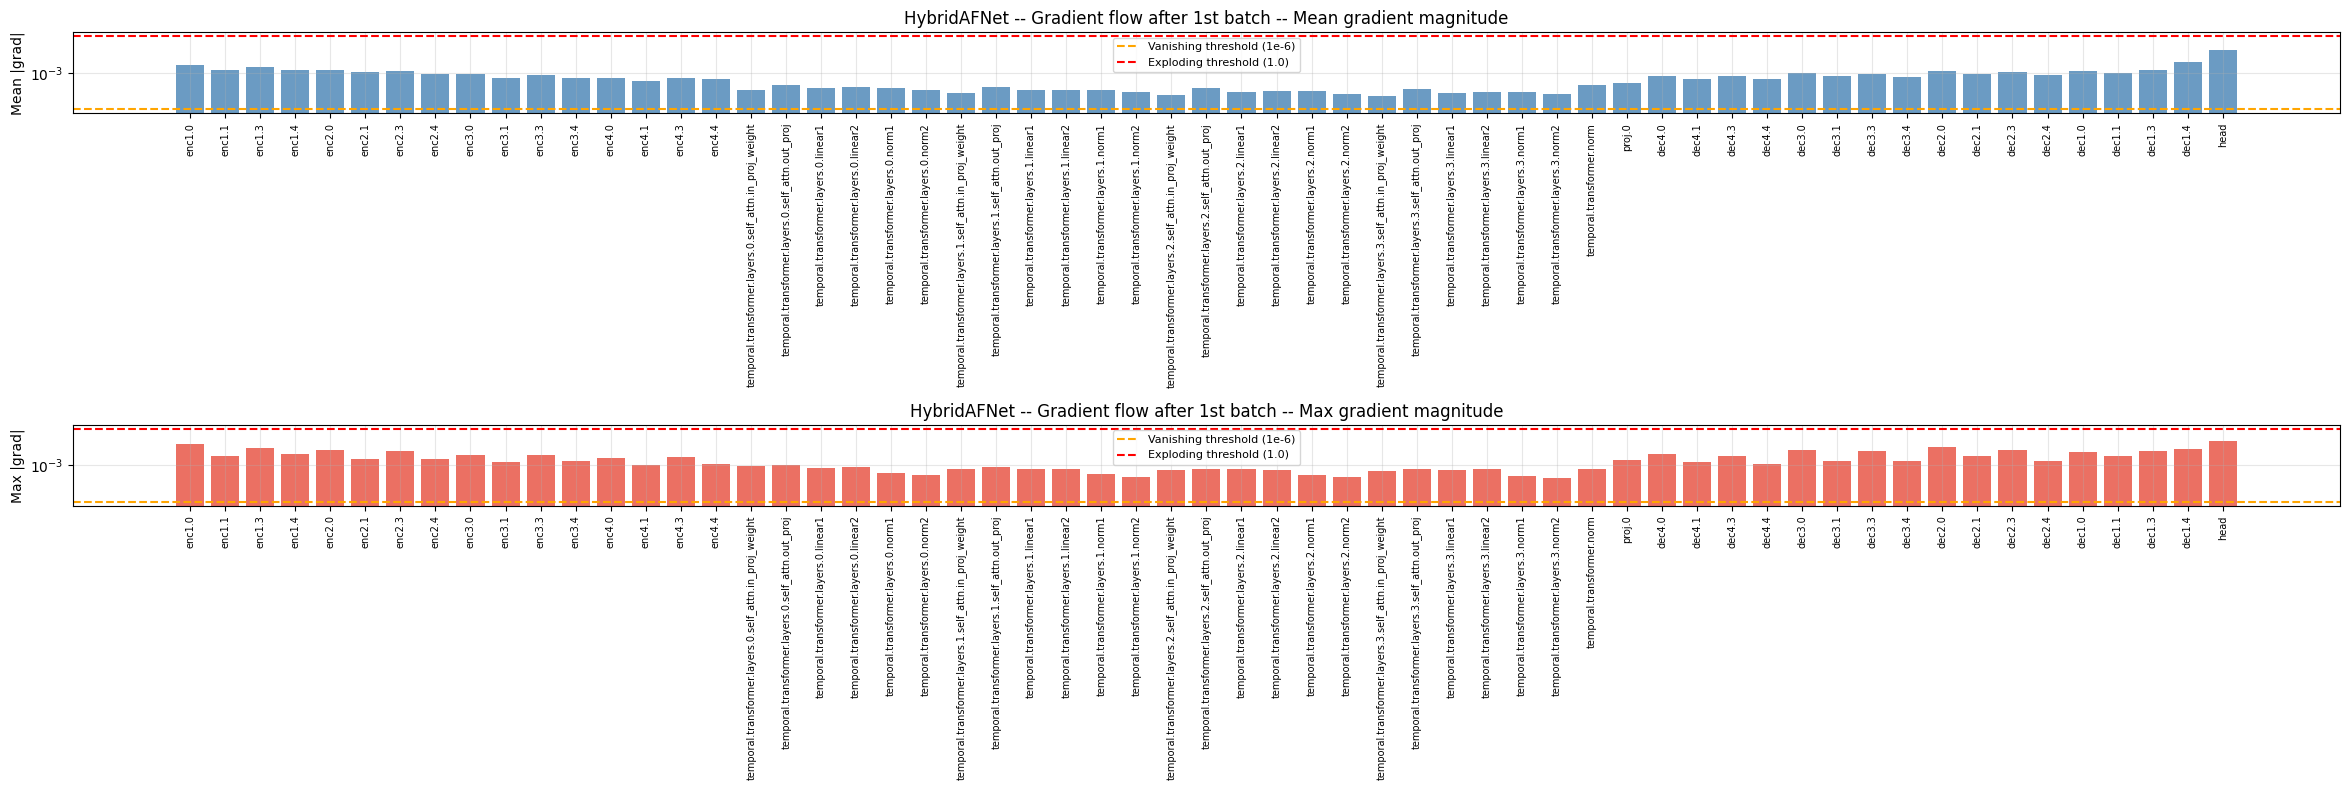


Block          Mean|grad|    Max|grad|     Params
--------------------------------------------------
enc1             3.10e-03     5.81e-02     24,384
enc2             1.45e-03     1.63e-02    124,800
enc3             6.89e-04     7.18e-03    498,432
enc4             3.55e-04     4.32e-03  1,992,192
temporal         3.63e-05     1.02e-03  3,951,104
proj             1.47e-04     2.74e-03    147,840
dec4             5.27e-04     8.12e-03  1,327,872
dec3             8.82e-04     1.61e-02    332,160
dec2             1.42e-03     3.09e-02     83,136
dec1             1.50e-03     2.89e-02     41,664
head             7.69e-02     2.10e-01         98


In [16]:
def plot_gradient_flow(model, title='Gradient Flow'):
    """Plot mean and max gradient magnitudes for all named parameters."""
    mean_grads, max_grads, names = [], [], []
    m = model.module if hasattr(model, 'module') else model
    for name, param in m.named_parameters():
        if param.grad is not None and 'weight' in name:
            mean_grads.append(param.grad.abs().mean().item())
            max_grads.append(param.grad.abs().max().item())
            names.append(name.replace('.weight', '').replace('.block.', '.'))

    if not names:
        print('No gradients found -- run a backward pass first')
        return

    fig, axes = plt.subplots(2, 1, figsize=(max(12, len(names)*0.4), 8))
    x = range(len(names))

    axes[0].bar(x, mean_grads, color='steelblue', alpha=0.8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names, rotation=90, fontsize=7)
    axes[0].set_ylabel('Mean |grad|')
    axes[0].set_title(f'{title} -- Mean gradient magnitude')
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)

    axes[1].bar(x, max_grads, color='#e74c3c', alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(names, rotation=90, fontsize=7)
    axes[1].set_ylabel('Max |grad|')
    axes[1].set_title(f'{title} -- Max gradient magnitude')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3)

    # Highlight vanishing gradient threshold
    for ax in axes:
        ax.axhline(1e-6, color='orange', lw=1.5, ls='--', label='Vanishing threshold (1e-6)')
        ax.axhline(1.0,  color='red',    lw=1.5, ls='--', label='Exploding threshold (1.0)')
        ax.legend(fontsize=8)

    plt.tight_layout()
    return fig


# Run one backward pass to populate gradients
model.train()
xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)

optimizer.zero_grad(set_to_none=True)
with torch.cuda.amp.autocast(enabled=use_amp):
    logits = model(xb)
    loss   = criterion(logits, yb)
scaler.scale(loss).backward()
scaler.unscale_(optimizer)

print(f'First batch loss : {loss.item():.4f}')

fig = plot_gradient_flow(model, title='HybridAFNet -- Gradient flow after 1st batch')
if SAVE_FIGURES and fig is not None:
    fig.savefig(os.path.join(OUTPUT_DIR, 'gradient_flow_af_v1.png'), dpi=120, bbox_inches='tight')
plt.show()

# Print gradient stats per block
m = model.module if hasattr(model, 'module') else model
blocks = {
    'enc1': m.enc1, 'enc2': m.enc2, 'enc3': m.enc3, 'enc4': m.enc4,
    'temporal': m.temporal, 'proj': m.proj,
    'dec4': m.dec4, 'dec3': m.dec3, 'dec2': m.dec2, 'dec1': m.dec1,
    'head': m.head,
}
print(f'\n{"Block":<12} {"Mean|grad|":>12} {"Max|grad|":>12} {"Params":>10}')
print('-' * 50)
for bname, block in blocks.items():
    grads  = [p.grad.abs() for p in block.parameters() if p.grad is not None]
    params = sum(p.numel() for p in block.parameters())
    if grads:
        all_g = torch.cat([g.flatten() for g in grads])
        print(f'{bname:<12} {all_g.mean().item():>12.2e} {all_g.max().item():>12.2e} {params:>10,}')
    else:
        print(f'{bname:<12} {"no grad":>12} {"":>12} {params:>10,}')

# Reset optimizer state after diagnostic
optimizer.zero_grad(set_to_none=True)

## Resume logic

In [17]:
if RESUME_WEIGHTS_DIR is not None:
    candidates = [
        os.path.join(RESUME_WEIGHTS_DIR, 'af_hybrid_v1_best.pt'),
        os.path.join(RESUME_WEIGHTS_DIR, 'af_hybrid_v1_last.pt'),
    ]
    resume_path = next((p for p in candidates if os.path.exists(p)), None)
    if resume_path:
        state = torch.load(resume_path, map_location=device)
        m_ref = model.module if hasattr(model, 'module') else model
        m_ref.load_state_dict(state)
        print(f'Resumed from : {resume_path}')
        # Rebuild scheduler with fine-tune LR
        for i, pg in enumerate(optimizer.param_groups):
            pg['lr'] = FINETUNE_LR_MAX / 10 if i == 0 else FINETUNE_LR_MAX / 10 * 0.3
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr          = [FINETUNE_LR_MAX, FINETUNE_LR_MAX * 0.3],
            steps_per_epoch = steps_per_epoch,
            epochs          = NUM_EPOCHS,
            pct_start       = 0.1,
            anneal_strategy = 'cos',
            div_factor      = 10.0,
            final_div_factor= 1e4,
        )
        print(f'Fine-tune scheduler: CNN peak={FINETUNE_LR_MAX:.1e}, Trans peak={FINETUNE_LR_MAX*0.3:.1e}')
    else:
        print(f'WARNING: RESUME_WEIGHTS_DIR set but no weights found. Training from scratch.')
else:
    print('No resume -- training from scratch.')

history = {
    'train_loss': [], 'train_F1': [], 'train_IoU': [],
    'train_mF1': [], 'train_precision': [], 'train_recall': [],
    'val_loss':   [], 'val_F1':   [], 'val_IoU':   [],
    'val_mF1':   [], 'val_precision':   [], 'val_recall':   [],
    'lr_cnn': [], 'lr_trans': [],
}
best_val_mf1 = 0.0
print('History initialised. Ready to train.')

No resume -- training from scratch.
History initialised. Ready to train.


## Training loop

In [18]:
# Reset scaler and optimizer state -- the gradient diagnostic cell earlier
# left the scaler in an already-unscaled state which would crash on the first batch.
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
optimizer.zero_grad(set_to_none=True)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    metrics    = FireMetrics()
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        bar = tqdm(loader, leave=False, desc='Train' if train else 'Val  ')
        for xb, yb in bar:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(xb)
                loss   = criterion(logits, yb)

            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()

            total_loss += loss.item()
            metrics.update(logits.detach(), yb)
            bar.set_postfix(loss=f'{loss.item():.4f}', F1=f'{metrics.F1:.3f}')

    n = len(loader)
    return {
        'loss'     : total_loss / n,
        'F1'       : metrics.F1,
        'IoU'      : metrics.IoU,
        'mF1'      : metrics.mF1,
        'precision': metrics.precision,
        'recall'   : metrics.recall,
    }


print(f'Starting training: {NUM_EPOCHS} epochs')
print(f'Train samples : {len(train_ds)}  ({len(train_loader)} batches)')
print(f'Val samples   : {len(val_ds)}   ({len(val_loader)} batches)')
print(f'Checkpoint criterion : val mF1')
header = (f'{"Ep":>3}  {"TrLoss":>8}  {"TrF1":>6}  {"TrmF1":>6}  '
          f'{"TrPrec":>7}  {"TrRec":>6}  '
          f'{"VaLoss":>8}  {"VaF1":>6}  {"VamF1":>6}  '
          f'{"VaPrec":>7}  {"VaRec":>6}  {"LR_CNN":>8}')
print('-' * len(header))
print(header)
print('-' * len(header))

start_time = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader,   train=False)

    lr_cnn   = optimizer.param_groups[0]['lr']
    lr_trans = optimizer.param_groups[1]['lr']

    for key in ['loss','F1','IoU','mF1','precision','recall']:
        history[f'train_{key}'].append(tr[key])
        history[f'val_{key}'].append(va[key])
    history['lr_cnn'].append(lr_cnn)
    history['lr_trans'].append(lr_trans)

    flag = ''
    if va['mF1'] > best_val_mf1:
        best_val_mf1 = va['mF1']
        m_ref = model.module if hasattr(model, 'module') else model
        torch.save(m_ref.state_dict(), CKPT_BEST)
        flag = '  [best]'

    m_ref = model.module if hasattr(model, 'module') else model
    torch.save(m_ref.state_dict(), CKPT_LAST)

    elapsed   = (time.time() - start_time) / 60
    remaining = elapsed / epoch * (NUM_EPOCHS - epoch)
    print(f'{epoch:>3}  {tr["loss"]:>8.4f}  {tr["F1"]:>6.4f}  {tr["mF1"]:>6.4f}  '
          f'{tr["precision"]:>7.4f}  {tr["recall"]:>6.4f}  '
          f'{va["loss"]:>8.4f}  {va["F1"]:>6.4f}  {va["mF1"]:>6.4f}  '
          f'{va["precision"]:>7.4f}  {va["recall"]:>6.4f}  '
          f'{lr_cnn:>8.2e}'
          f'  [{elapsed:.0f}m/{remaining:.0f}m rem]{flag}')

    if epoch % 5 == 0:
        with open(HIST_PATH, 'w') as f:
            json.dump(history, f)

with open(HIST_PATH, 'w') as f:
    json.dump(history, f)
print(f'\nTraining complete. Best val mF1 : {best_val_mf1:.4f}')

Starting training: 40 epochs
Train samples : 1733  (288 batches)
Val samples   : 138   (23 batches)
Checkpoint criterion : val mF1
---------------------------------------------------------------------------------------------------
 Ep    TrLoss    TrF1   TrmF1   TrPrec   TrRec    VaLoss    VaF1   VamF1   VaPrec   VaRec    LR_CNN
---------------------------------------------------------------------------------------------------


Train:   0%|          | 0/288 [00:06<?, ?it/s]

Val  :   0%|          | 0/23 [00:00<?, ?it/s]

  1    0.7043  0.1654  0.2632   0.0911  0.8977    0.6211  0.4646  0.3855   0.3109  0.9196  2.31e-05  /601m rem]  [best]


Train:   0%|          | 0/288 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/23 [00:00<?, ?it/s]

 39    0.1581  0.7945  0.6463   0.7281  0.8742    0.1808  0.7812  0.6141   0.7181  0.8566  6.26e-07  /14m rem]


Train:   0%|          | 0/288 [00:00<?, ?it/s]

Val  :   0%|          | 0/23 [00:00<?, ?it/s]

 40    0.1579  0.7943  0.6471   0.7283  0.8733    0.1803  0.7837  0.6169   0.7247  0.8530  2.01e-09  /0m rem]  [best]

Training complete. Best val mF1 : 0.6169


## Training curves

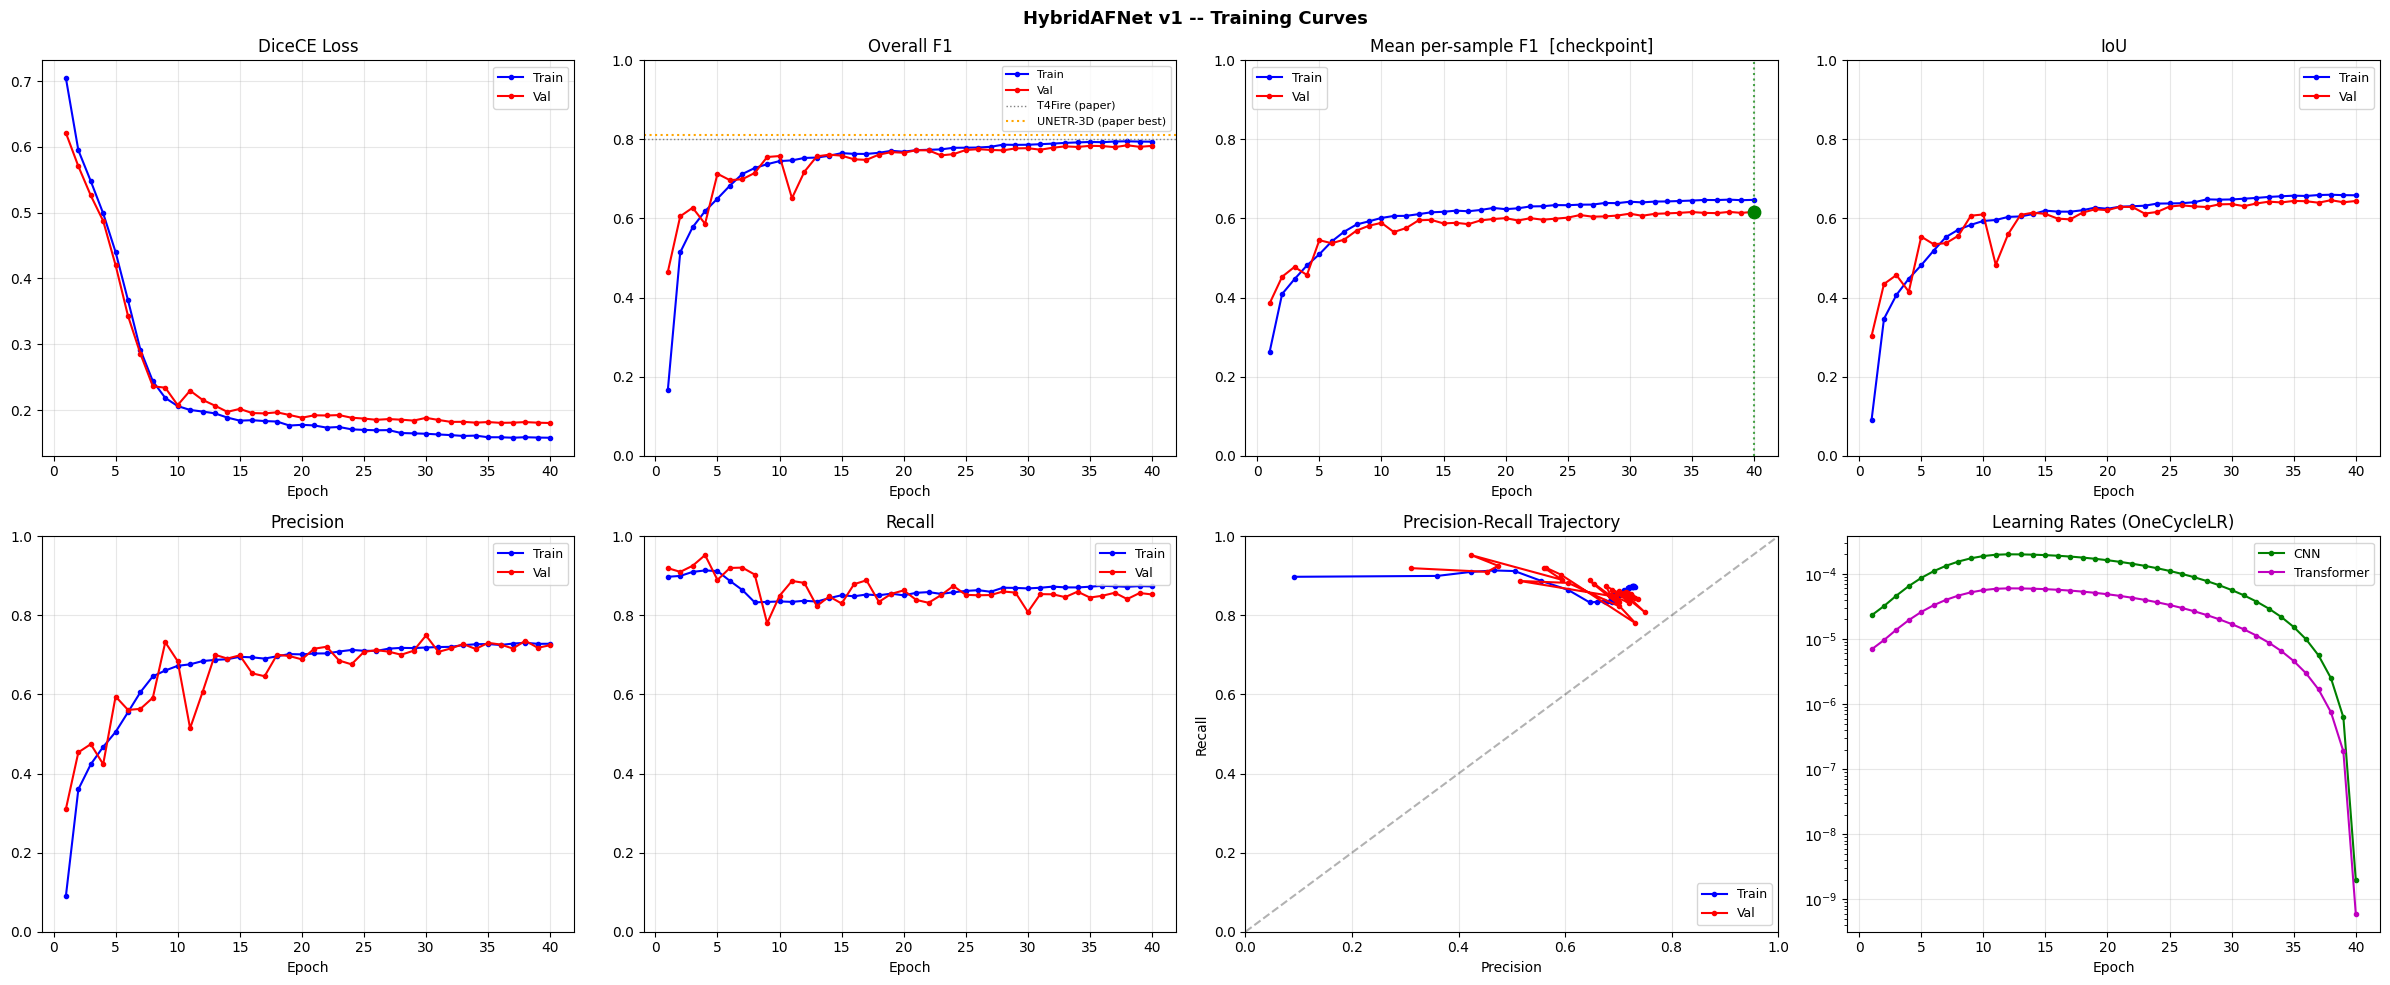

In [19]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(2, 4, figsize=(24, 10))

def plot_metric(ax, key, title, ylim=None):
    ax.plot(epochs, history[f'train_{key}'], 'b-o', markersize=3, label='Train')
    ax.plot(epochs, history[f'val_{key}'],   'r-o', markersize=3, label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    if ylim: ax.set_ylim(*ylim)
    # Mark best val mF1 epoch
    if key == 'mF1':
        best_ep = int(np.argmax(history['val_mF1'])) + 1
        best_v  = max(history['val_mF1'])
        ax.axvline(best_ep, color='green', lw=1.5, ls=':', alpha=0.7)
        ax.scatter([best_ep], [best_v], color='green', s=80, zorder=5)

plot_metric(axes[0,0], 'loss',      'DiceCE Loss')
plot_metric(axes[0,1], 'F1',        'Overall F1',        ylim=(0, 1))
plot_metric(axes[0,2], 'mF1',       'Mean per-sample F1  [checkpoint]', ylim=(0, 1))
plot_metric(axes[0,3], 'IoU',       'IoU',               ylim=(0, 1))
plot_metric(axes[1,0], 'precision', 'Precision',         ylim=(0, 1))
plot_metric(axes[1,1], 'recall',    'Recall',            ylim=(0, 1))

# Precision-Recall plane
axes[1,2].plot(history['train_precision'], history['train_recall'],
               'b-o', markersize=3, label='Train')
axes[1,2].plot(history['val_precision'],   history['val_recall'],
               'r-o', markersize=3, label='Val')
axes[1,2].set_xlabel('Precision')
axes[1,2].set_ylabel('Recall')
axes[1,2].set_title('Precision-Recall Trajectory')
axes[1,2].set_xlim(0, 1); axes[1,2].set_ylim(0, 1)
axes[1,2].plot([0,1],[0,1], 'k--', alpha=0.3)
axes[1,2].legend(fontsize=9)
axes[1,2].grid(True, alpha=0.3)

# Learning rates
axes[1,3].plot(epochs, history['lr_cnn'],   'g-o', markersize=3, label='CNN')
axes[1,3].plot(epochs, history['lr_trans'], 'm-o', markersize=3, label='Transformer')
axes[1,3].set_title('Learning Rates (OneCycleLR)')
axes[1,3].set_xlabel('Epoch')
axes[1,3].set_yscale('log')
axes[1,3].legend(fontsize=9)
axes[1,3].grid(True, alpha=0.3)

# Paper baseline reference lines on F1 plot
axes[0,1].axhline(0.802, color='gray', lw=1, ls=':', label='T4Fire (paper)')
axes[0,1].axhline(0.811, color='orange', lw=1.5, ls=':', label='UNETR-3D (paper best)')
axes[0,1].legend(fontsize=8)

plt.suptitle('HybridAFNet v1 -- Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves_af_v1.png'), dpi=150, bbox_inches='tight')
plt.show()

## Post-training diagnostic: precision-recall analysis

Threshold sweep results (val set):
 Threshold       F1  Precision   Recall
----------------------------------------
      0.10   0.7481     0.6320   0.9165
      0.15   0.7602     0.6568   0.9022
      0.20   0.7675     0.6738   0.8915
      0.25   0.7719     0.6858   0.8828
      0.30   0.7753     0.6957   0.8754
      0.35   0.7780     0.7042   0.8691
      0.40   0.7801     0.7114   0.8634
      0.45   0.7819     0.7182   0.8580
      0.50   0.7836     0.7247   0.8530
      0.55   0.7845     0.7307   0.8469
      0.60   0.7857     0.7374   0.8408
      0.65   0.7864     0.7434   0.8348
      0.70   0.7866     0.7496   0.8275
      0.75   0.7868     0.7572   0.8189 <-- best
      0.80   0.7863     0.7650   0.8089
      0.85   0.7847     0.7746   0.7951
      0.90   0.7816     0.7881   0.7752

Best threshold : 0.75  (F1=0.7868)
Default threshold (0.5) F1 : 0.7836


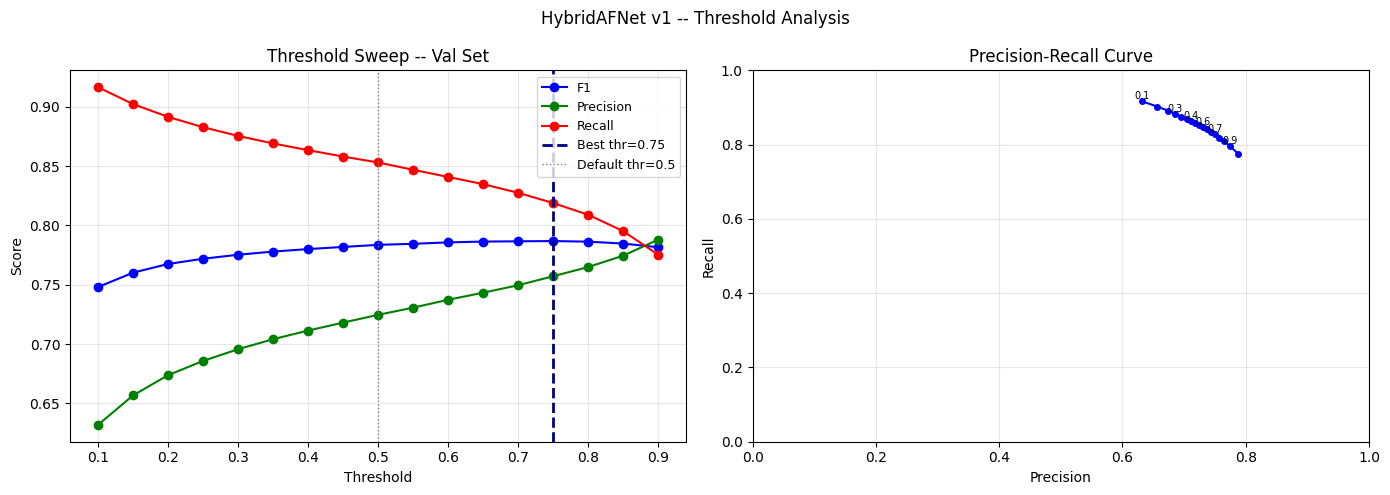

In [20]:
# Reload best checkpoint and compute metrics at multiple thresholds
eval_model = HybridAFNet(
    in_ch=CHANS_PER_STEP, base_ch=BASE_CH,
    n_heads=N_HEADS, n_layers=N_TRANS_LAYERS,
    ff_dim=TRANS_FF_DIM, dropout=TRANS_DROPOUT
).to(device)
eval_model.load_state_dict(torch.load(CKPT_BEST, map_location=device))
eval_model.eval()

thresholds = np.arange(0.1, 0.95, 0.05)
all_probs, all_labels = [], []

with torch.no_grad():
    for xb, yb in tqdm(val_loader, desc='Collecting probs', leave=False):
        xb = xb.to(device)
        xp, H_orig, W_orig = pad_to_multiple(xb)
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = eval_model(xp)
        logits = logits[:, :, :H_orig, :W_orig]
        probs  = torch.softmax(logits.float(), dim=1)[:, 1]
        all_probs.append(probs.cpu().numpy().ravel())
        all_labels.append(yb.numpy().ravel())

all_probs  = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

f1_scores, prec_scores, rec_scores = [], [], []
for thr in thresholds:
    preds = (all_probs > thr).astype(int)
    tp = int((preds * all_labels).sum())
    fp = int((preds * (1 - all_labels)).sum())
    fn = int(((1 - preds) * all_labels).sum())
    f1   = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_scores.append(f1)
    prec_scores.append(prec)
    rec_scores.append(rec)

best_thr_idx = int(np.argmax(f1_scores))
best_thr     = thresholds[best_thr_idx]
best_f1      = f1_scores[best_thr_idx]

print(f'Threshold sweep results (val set):')
print(f'{"Threshold":>10} {"F1":>8} {"Precision":>10} {"Recall":>8}')
print('-' * 40)
for i, thr in enumerate(thresholds):
    flag = ' <-- best' if i == best_thr_idx else ''
    print(f'{thr:>10.2f} {f1_scores[i]:>8.4f} {prec_scores[i]:>10.4f} {rec_scores[i]:>8.4f}{flag}')

print(f'\nBest threshold : {best_thr:.2f}  (F1={best_f1:.4f})')
print(f'Default threshold (0.5) F1 : {f1_scores[list(thresholds).index(min(thresholds, key=lambda x: abs(x-0.5)))]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresholds, f1_scores,   'b-o', label='F1')
axes[0].plot(thresholds, prec_scores, 'g-o', label='Precision')
axes[0].plot(thresholds, rec_scores,  'r-o', label='Recall')
axes[0].axvline(best_thr, color='navy', lw=2, ls='--', label=f'Best thr={best_thr:.2f}')
axes[0].axvline(0.5,      color='gray', lw=1, ls=':',  label='Default thr=0.5')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Sweep -- Val Set')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(prec_scores, rec_scores, 'b-o', markersize=4)
for i, thr in enumerate(thresholds[::3]):
    idx = i*3
    axes[1].annotate(f'{thr:.1f}', (prec_scores[idx], rec_scores[idx]),
                     fontsize=7, ha='center', va='bottom')
axes[1].set_xlabel('Precision')
axes[1].set_ylabel('Recall')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.suptitle('HybridAFNet v1 -- Threshold Analysis', fontsize=12)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR, 'threshold_analysis_af_v1.png'), dpi=150, bbox_inches='tight')
plt.show()

# Update run_meta with best threshold
run_meta['best_threshold'] = float(best_thr)
run_meta['val_F1_at_best_thr'] = float(best_f1)
with open(META_PATH, 'w') as f:
    json.dump(run_meta, f, indent=2)

## Final validation metrics with best checkpoint

In [21]:
# Evaluate with best checkpoint at best threshold
val_metrics = FireMetrics()
eval_model.eval()
with torch.no_grad():
    for xb, yb in tqdm(val_loader, desc='Final val eval', leave=False):
        xb = xb.to(device)
        xp, H_orig, W_orig = pad_to_multiple(xb)
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = eval_model(xp)
        logits = logits[:, :, :H_orig, :W_orig]
        val_metrics.update(logits, yb, threshold=best_thr)

print(f'Final val results (threshold={best_thr:.2f}):')
print(f'  F1        : {val_metrics.F1:.4f}')
print(f'  IoU       : {val_metrics.IoU:.4f}')
print(f'  mF1       : {val_metrics.mF1:.4f}')
print(f'  Precision : {val_metrics.precision:.4f}')
print(f'  Recall    : {val_metrics.recall:.4f}')
print(f'  TP        : {val_metrics.tp:,}')
print(f'  FP        : {val_metrics.fp:,}')
print(f'  FN        : {val_metrics.fn:,}')
print(f'  FP/FN     : {val_metrics.fp/(val_metrics.fn+1e-6):.2f}')
print(f'\nPaper baselines (AF test set):')
print(f'  T4Fire    : F1=0.802, IoU=0.700')
print(f'  UNETR-3D  : F1=0.811, IoU=0.706  (paper best)')

Final val eval:   0%|          | 0/23 [00:00<?, ?it/s]

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

## Output files and zip

In [ ]:
output_files = [
    'af_hybrid_v1_best.pt',
    'af_hybrid_v1_last.pt',
    'norm_stats_af_v1.npz',
    'run_meta_af_v1.json',
    'history_af_v1.json',
    'model_summary_af_v1.txt',
    'eda_af_v1.png',
    'norm_stats_af_v1.png',
    'label_density_af_v1.png',
    'gradient_flow_af_v1.png',
    'training_curves_af_v1.png',
    'threshold_analysis_af_v1.png',
]

zip_path = os.path.join(OUTPUT_DIR, 'af_hybrid_v1_outputs.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in output_files:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            zf.write(fpath, arcname=fname)
            size_kb = os.path.getsize(fpath) / 1024
            print(f'  added  {fname:<45} {size_kb:>8.1f} KB')
        else:
            print(f'  SKIP   {fname:<45} (not found)')

zip_size = os.path.getsize(zip_path) / 1024**2
print(f'\nZip : {zip_path}  ({zip_size:.1f} MB)')

print('\nAll /kaggle/working files:')
print('=' * 60)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if not os.path.isfile(fpath): continue
    sz  = os.path.getsize(fpath)
    u   = 'MB' if sz >= 1024**2 else 'KB'
    val = sz/1024**2 if u == 'MB' else sz/1024
    print(f'  {fname:<50} {val:>7.1f} {u}')